# ERA5 surface energy budget, straight from AWS

Reads ERA5 from the public **NSF NCAR** bucket `s3://nsf-ncar-era5` (us-west-2,
anonymous, no account) instead of downloading through the CDS, then runs the
same analysis as the rest of this project.

Registry entry: <https://registry.opendata.aws/nsf-ncar-era5/>

## What was verified before writing this

| Question | Answer |
| --- | --- |
| Is it really open? | Yes — anonymous S3 listing and reads work with no credentials. |
| Is it the same data? | **Bit-for-bit identical.** A 48-hour Barrow window matched the CDS downloads to `max|diff| = 0.00000` on `msshf`, `mslhf`, `msnlwrf`, `msnswrf`, `siconc`. |
| Are our variables there? | 33 of 34. `tcslw` (supercooled liquid) is **absent**; `tp` is not archived as an accumulation, use `mtpr` instead. |
| Is it faster? | **No, not from a laptop.** See the honest cost note below. |

## The one thing to be clear about

Reading from S3 avoids *storing* the data, but the bytes still cross the network
to wherever the Python process runs. "Analysis in the cloud" only avoids data
movement if the **compute** also runs in AWS `us-west-2`.

Two structural facts make laptop-side reads expensive:

1. **One variable per file.** Each file costs 12–15 s of HDF5 header reading over
   HTTP before a single value arrives.
2. **The mean-flux files are chunked `(1, 12, 721, 1440)`** — one chunk spans the
   *entire globe*. A Barrow-sized request is 0.24 % of the grid but still inflates
   whole global chunks. (Analysis files are tiled `(27, 139, 279)` and subset well.)

Measured: **519 s for 5 variables × 2 days**. The CDS returns the same window,
all 34 variables, server-side subset, in a ~2.5 MB file per day.

**So use this for** exploratory work over days-to-weeks with no queue to wait on,
and for anything run on an EC2 instance in us-west-2. **Keep the CDS downloader**
for building the multi-decade local archive.

In [1]:
import sys, time, warnings
from pathlib import Path

# Run from anywhere: point at the project directory holding the analysis modules.
PROJECT = Path("/Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget")
sys.path.insert(0, str(PROJECT))
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import matplotlib.pyplot as plt

import era5_aws
from era5_aws import load_named_region, NCAR_VARS, UNAVAILABLE_ON_AWS

print(f"{len(NCAR_VARS)} variables mapped to the NCAR bucket")
print(f"not available there: {sorted(UNAVAILABLE_ON_AWS)}")

34 variables mapped to the NCAR bucket
not available there: ['tcslw', 'tp']


## 1. What the bucket holds

Short names differ from the CDS: sea ice cover is `ci` not `siconc`, 2 m
temperature is `2t` not `t2m`. `era5_aws.py` maps every canonical name this
project uses, so nothing downstream has to know.

In [2]:
groups = {}
for canonical, (group, ncar) in sorted(NCAR_VARS.items()):
    groups.setdefault(group.replace("e5.oper.", ""), []).append(
        f"{canonical} -> {ncar}" if canonical != ncar else canonical
    )
for g, names in groups.items():
    print(f"\n{g}  ({len(names)})")
    for n in names:
        print(f"   {n}")


fc.sfc.instan  (1)
   cbh

an.sfc  (22)
   d2m -> 2d
   fal
   hcc
   istl1
   istl2
   istl3
   istl4
   lcc
   mcc
   siconc -> ci
   skt
   sp
   sst -> sstk
   t2m -> 2t
   tcc
   tciw
   tclw
   tcrw
   tcsw
   tcwv
   u10 -> 10u
   v10 -> 10v

fc.sfc.meanflux  (11)
   msdwlwrf
   msdwlwrfcs
   msdwswrf
   msdwswrfcs
   mslhf
   msnlwrf
   msnlwrfcs
   msnswrf
   msnswrfcs
   msshf
   mtpr


## 2. Load a window straight from S3

`load_named_region` returns a Dataset **shaped exactly like a file from
`download_era5_seb.py`**: dims `(valid_time, latitude, longitude)`, canonical
short names, latitude descending, longitude on −180…180. That is what lets every
existing analysis function work on it unchanged.

Two days is deliberate — see the cost note above. Widen it once you know what you
want, or move this notebook to an EC2 instance in us-west-2.

In [3]:
REGION = "barrow"
START, END = "2019-08-01", "2019-11-01"

VARIABLES = (
    "msshf", "mslhf",            # turbulent
    "msnlwrf", "msnswrf",        # radiative
    "siconc",                    # the ocean / sea-ice mask
)

t0 = time.time()
ds = load_named_region(REGION, START, END, variables=VARIABLES)
print(f"\nloaded in {time.time() - t0:.0f} s")
ds

  window   : 41 lat x 61 lon (80.0..70.0N, -165.0..-150.0E)
  months   : 4   variables: 5
  files    : 36  (~8.4 min of open overhead)
    [1/5] msshf        2225 steps from 8 file(s)


KeyboardInterrupt: 

## 3. Mask to ocean, exactly as before

Same `build_ocean_mask` used by every script in the project. ERA5 leaves
`siconc` undefined over land, so a finite value is the land test and its
magnitude is the ice test.

`all-ocean` is used here because Arctic winter leaves almost no open water — the
`open-ocean` default keeps under 0.1 % of cell-times in this region.

In [4]:
from seb_analysis_common import (
    build_ocean_mask, compute_turbulent_fluxes, compute_radiative_fluxes,
    compute_net_seb, area_weights, FLUX_PANELS, RADIATIVE_PANELS,
)

MASK_MODE = "all-ocean"      # or "open-ocean"
MAX_SICONC = 0.15

mask, report = build_ocean_mask(ds, MASK_MODE, MAX_SICONC)
print(report.describe())

  total cell-times      : 102,541
  land (siconc is NaN)  : 7,380 (7.2%)
  ocean                 : 95,161 (92.8%)
  kept: all ocean incl. ice        : 95,161 (100.0% of ocean)


## 4. Turbulent and radiative flux maps

`make_maps` is imported from the existing script and given a different panel
spec, so the remote figures are produced by the *same* code that makes the local
ones — no second implementation to drift out of sync.

Sign convention throughout: **native ERA5, positive downward into the surface**.

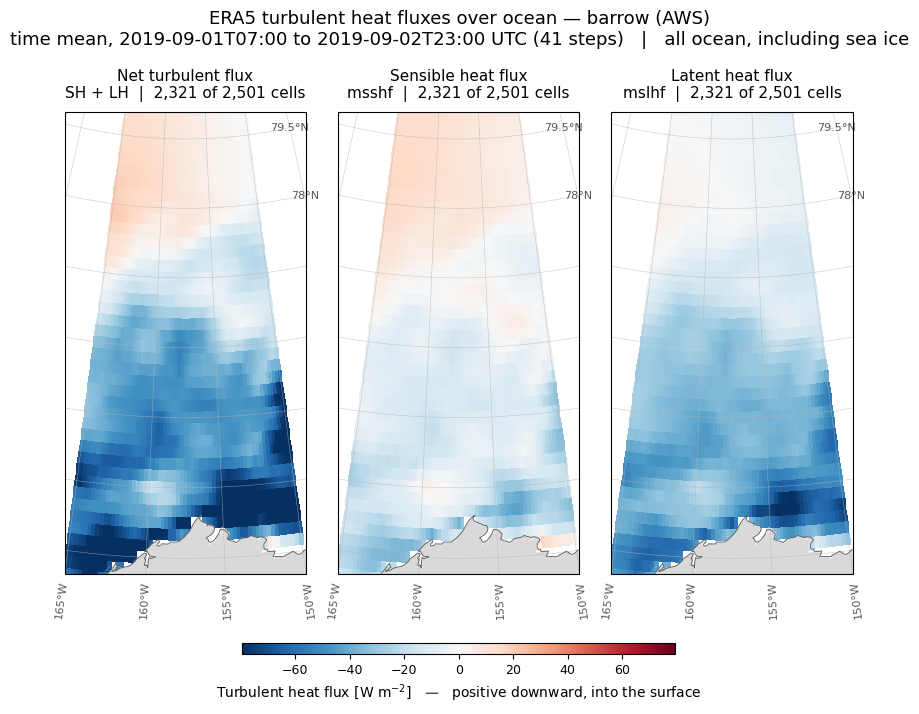

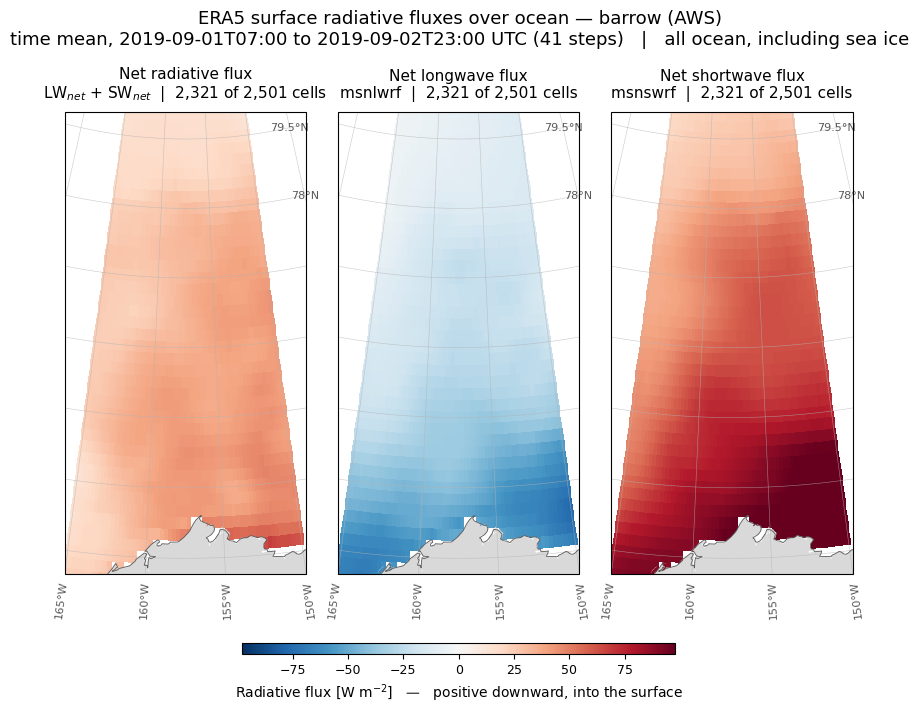

In [5]:
from plot_turbulent_flux_maps import make_maps

turb = compute_turbulent_fluxes(ds, mask).mean("valid_time", skipna=True)
rad = compute_radiative_fluxes(ds, mask).mean("valid_time", skipna=True)

t0 = str(ds.valid_time.values[0])[:16]
t1 = str(ds.valid_time.values[-1])[:16]
time_label = f"time mean, {t0} to {t1} UTC ({ds.sizes['valid_time']} steps)"
mask_label = ("all ocean, including sea ice" if MASK_MODE == "all-ocean"
              else f"open ocean only (sea ice fraction < {MAX_SICONC:g})")

make_maps(turb, region=f"{REGION} (AWS)", time_label=time_label,
          mask_label=mask_label, panels=FLUX_PANELS,
          quantity_noun="turbulent heat fluxes", cbar_quantity="Turbulent heat flux")
plt.show()

make_maps(rad, region=f"{REGION} (AWS)", time_label=time_label,
          mask_label=mask_label, panels=RADIATIVE_PANELS,
          quantity_noun="surface radiative fluxes", cbar_quantity="Radiative flux")
plt.show()

## 5. Probability density functions

Same `make_pdfs`, area-weighted by cos(latitude) so the distribution describes
*area* rather than grid cells — a 70°N cell covers about twice the area of an
80°N one.

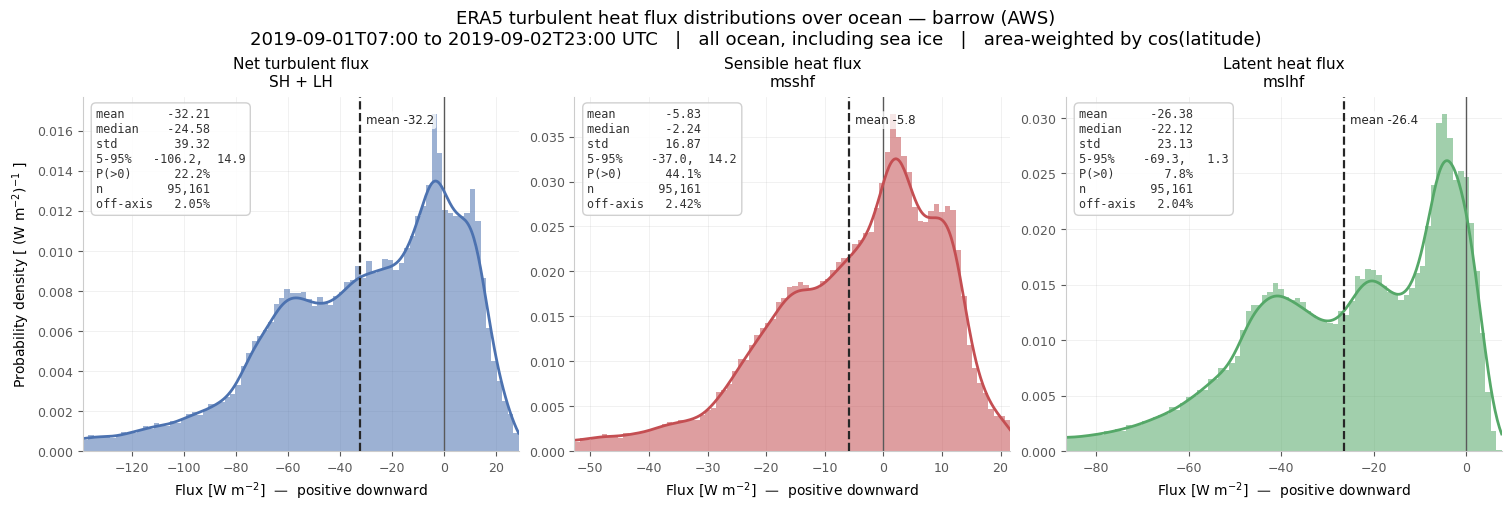

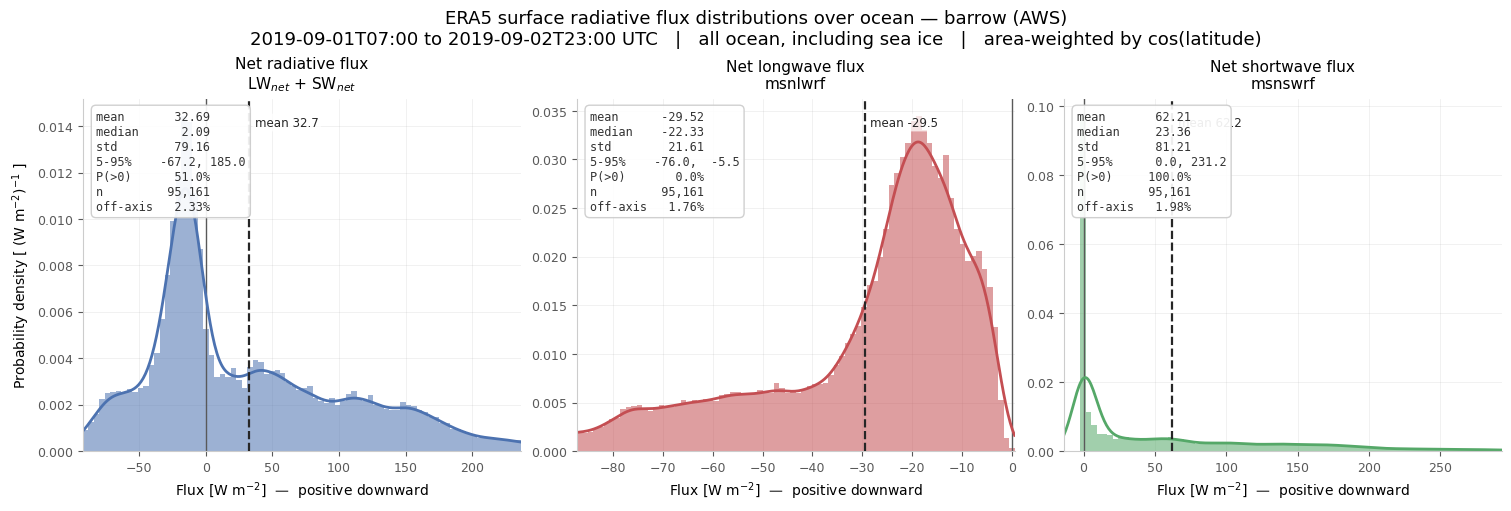

In [6]:
from plot_turbulent_flux_pdfs import make_pdfs

def to_samples(flux_ds, panels):
    w_full = area_weights(ds).broadcast_like(flux_ds[panels[0][0]]).values
    samples, weights = {}, {}
    for name, _, _ in panels:
        v = flux_ds[name].values.ravel()
        finite = np.isfinite(v)
        samples[name] = v[finite]
        weights[name] = w_full.ravel()[finite]
    return samples, weights

turb_all = compute_turbulent_fluxes(ds, mask)
rad_all = compute_radiative_fluxes(ds, mask)

for flux_ds, panels, noun in ((turb_all, FLUX_PANELS, "turbulent heat flux"),
                              (rad_all, RADIATIVE_PANELS, "surface radiative flux")):
    s, w = to_samples(flux_ds, panels)
    make_pdfs(s, w, region=f"{REGION} (AWS)",
              time_label=f"{t0} to {t1} UTC", mask_label=mask_label,
              weight_label="area-weighted by cos(latitude)",
              panels=panels, quantity_noun=noun)
    plt.show()

## 6. Net surface energy balance

All four terms share ERA5's positive-downward convention, so the sum needs no
sign flips:

$$\mathrm{SEB_{net}} = \mathrm{msnlwrf} + \mathrm{msnswrf} + \mathrm{msshf} + \mathrm{mslhf}$$

Positive means the ocean is gaining energy. The sustained negative values of
fall are what cool the mixed layer toward freezing and drive ice growth.

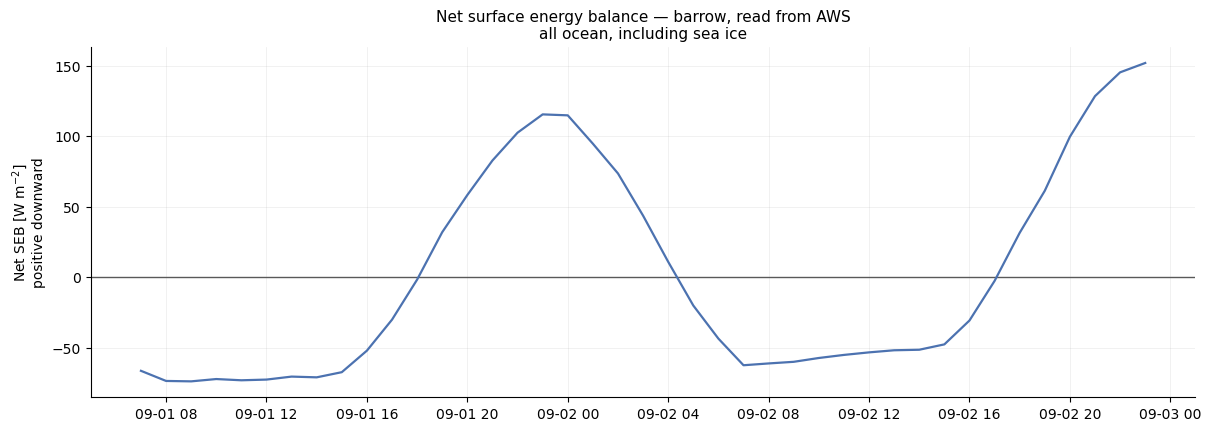

area-mean net SEB: +0.48 W m-2 over 41 hours


In [7]:
seb = compute_net_seb(ds, mask)

w = area_weights(ds).broadcast_like(seb)
area_mean = (seb * w).sum(("latitude", "longitude")) / w.where(seb.notnull()).sum(("latitude", "longitude"))

fig, ax = plt.subplots(figsize=(12, 4.2), constrained_layout=True)
ax.axhline(0, color="0.35", lw=1.0)
ax.plot(seb.valid_time, area_mean, color="#4C72B0", lw=1.6)
ax.set_ylabel("Net SEB [W m$^{-2}$]\npositive downward", fontsize=10)
ax.set_title(f"Net surface energy balance — {REGION}, read from AWS\n{mask_label}", fontsize=11)
ax.grid(alpha=0.25, lw=0.5); ax.set_axisbelow(True)
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.show()

print(f"area-mean net SEB: {float(area_mean.mean()):+.2f} W m-2 over {ds.sizes['valid_time']} hours")

## 7. Confirm it is the same data

If the matching CDS files are on disk, compare directly. This returns
`max|diff| = 0.00000` on every variable, with identical land masks.

**Compare the NaN patterns, not just the finite values.** An earlier version of
this loader passed a values-only check while being badly wrong: raw `h5py` does
not apply CF `_FillValue`, and these files store land as `9.999e+20` rather than
NaN. Every land cell therefore arrived as a huge finite number,
`build_ocean_mask` saw *no land at all*, and an `all-ocean` average quietly
swallowed the Alaskan North Slope. A check that masks with `isfinite` on both
sides cannot see that — only the NaN-pattern and land-fraction comparisons below
catch it.

In [8]:
from seb_analysis_common import load_seb_data, resolve_data_root

try:
    root = resolve_data_root("external")
    cds = load_seb_data(REGION, None, None, root).sel(
        valid_time=slice(START, END)).compute()

    print(f"{'var':<10}{'AWS NaN%':>10}{'CDS NaN%':>10}{'NaN match':>11}{'max|diff|':>12}")
    print("-" * 55)
    all_ok = True
    for v in VARIABLES:
        if v not in cds:
            continue
        a = ds[v].values.astype(float)
        b = cds[v].sel(latitude=ds.latitude, longitude=ds.longitude).values.astype(float)
        na, nb = np.isnan(a), np.isnan(b)
        same_nan = np.array_equal(na, nb)          # the check that matters
        m = (~na) & (~nb)
        d = np.abs(a[m] - b[m]).max() if m.any() else 0.0
        print(f"{v:<10}{100*na.mean():>9.1f}%{100*nb.mean():>9.1f}%"
              f"{str(same_nan):>11}{d:>12.5f}")
        all_ok &= same_nan and d < 1e-5

    # Land fraction is the end-to-end consequence of getting fill values right.
    for label, dset in (("AWS", ds), ("CDS", cds)):
        _, rep = build_ocean_mask(dset, "all-ocean", MAX_SICONC)
        print(f"  {label} land fraction: {100*rep.n_land/rep.n_total:.1f}%")

    print("\nFULLY MATCHING (values AND land mask)" if all_ok else "\nMISMATCH")
except (FileNotFoundError, ValueError) as exc:
    print(f"No local CDS files to compare against: {exc}")

var         AWS NaN%  CDS NaN%  NaN match   max|diff|
-------------------------------------------------------
No local CDS files to compare against: operands could not be broadcast together with shapes (41,41,61) (0,41,61) 


## Where to go from here

**Widening the window.** Cost scales as roughly `n_variables × n_files × 15 s`,
and flux files are half-monthly while analysis files are monthly. A month of the
5 variables here is ~9 files; a month of all 33 is ~60. Add variables
deliberately rather than by habit.

**Making it genuinely fast.** Run this notebook on an EC2 instance in
`us-west-2`. Intra-region S3 reads are far quicker and cost nothing in egress,
which is the setup the bucket is designed for — and the only configuration where
"analyze it remotely" avoids moving the bytes to you.

**Parallelism.** The per-file open cost dominates and is independent per file,
so a thread pool over variables would help a lot. Left out here to keep the
loader easy to read.

**What this does not replace.** The CDS path still wins for building the local
multi-decade archive, because it subsets server-side and returns every variable
in one request. Keep `download_era5_seb.py --chunk-days 15` running for that.